In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures,LabelEncoder,OneHotEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report




In [3]:
df=pd.read_csv('loan_data (2).csv')
x=df.drop('loan_status',axis=1) 
y=df['loan_status'] 

In [4]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
num_col=x.select_dtypes(exclude='object').columns
cat_col=x.select_dtypes(include='object').columns

In [ ]:
scaler=StandardScaler()
label=LabelEncoder()
one=OneHotEncoder()

In [6]:
x_train[num_col]=scaler.fit_transform(x_train[num_col])
x_test[num_col]=scaler.transform(x_test[num_col])

In [ ]:
# for i in cat_col:
#     x_train[i]=label.fit_transform(x_train[i])
#     x_test[i]=label.transform(x_test[i])
train_cat_arr=one.fit_transform(x_train[cat_col])
train_cat=one.transform(x_test[cat_col])

In [ ]:
train_cat = pd.DataFrame(
    columns=one.get_feature_names_out(cat_col),
    index=x_train.index  
)

test_cat = pd.DataFrame(
    columns=one.get_feature_names_out(cat_col),
    index=x_test.index
)

In [9]:
x_train=x_train.drop(columns=cat_col)
x_test=x_test.drop(columns=cat_col)

x_train=pd.concat([x_train,train_cat],axis=1)
x_test=pd.concat([x_test,test_cat],axis=1)

In [10]:
x_train.dropna(axis=1, inplace=True)
x_test.dropna(axis=1, inplace=True)

In [11]:
model = LogisticRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

In [12]:
print("confusion_matrix:",confusion_matrix(y_test,y_pred))
print("accuracy_score:",accuracy_score(y_test,y_pred))
print("classification_report:",classification_report(y_test,y_pred))

confusion_matrix: [[6602  388]
 [1193  817]]
accuracy_score: 0.8243333333333334
classification_report:               precision    recall  f1-score   support

           0       0.85      0.94      0.89      6990
           1       0.68      0.41      0.51      2010

    accuracy                           0.82      9000
   macro avg       0.76      0.68      0.70      9000
weighted avg       0.81      0.82      0.81      9000



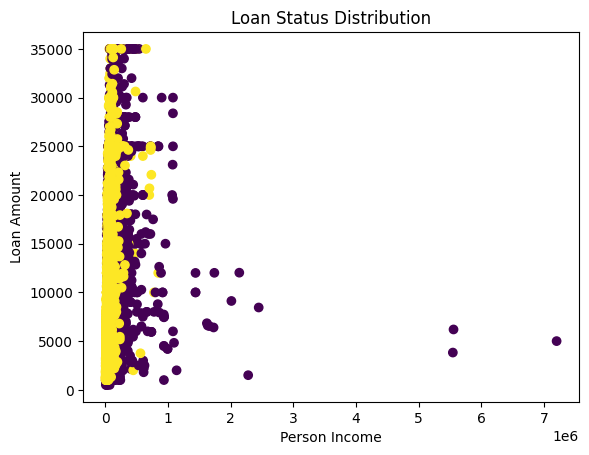

In [13]:
plt.figure()
plt.scatter(
    df['person_income'],
    df['loan_amnt'],        
    c=df['loan_status']
)
plt.xlabel("Person Income")
plt.ylabel("Loan Amount")
plt.title("Loan Status Distribution")
plt.show()